<div style="background-color:#5A3516; color:#F3EEE6; padding:22px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h1 style="color:#F3EEE6; margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="color:#D8C0B4; margin-top:6px;">Notebook 3 — Clustering Modelling and Validation</h3>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Workflow overview.</b> This notebook develops the segmentation as a sequence of modelling decisions rather than as a single KMeans run. Alternative feature spaces, scalers and clustering families are compared first; the final solution is then validated through silhouette analysis, hierarchical benchmarks, based on density checks, consensus stability and business profiling. The final labels are interpreted using the full customer profile, while the distance calculation is kept focused on the variables that best separate purchasing behaviour.
</div>


<div style="background-color:#5A3516; color:#F3EEE6; padding:18px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin-top:0;"><b>Index</b></h2>
<ol>
<li>Imports and data loading</li>
<li>Candidate feature sets and scalers</li>
<li>Diagnostics A — scaler comparison, elbow and dendrograms</li>
<li>Diagnostics B — feature set × k silhouette grid</li>
<li>Model configuration</li>
<li>Model fitting and validation</li>
<li>Method benchmarks before ensemble</li>
<li>Ensemble / consensus clustering</li>
<li>Segment profiling</li>
<li>Reattach outliers and export</li>
<li>Final modelling conclusion</li>
</ol>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1) Imports and data loading</b></h2>
</div>

In [40]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

import utils_clustering as uc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

In [41]:
DATA_DIR = Path("../datasets")

regular = pd.read_csv(DATA_DIR / "info_clustering_unscaled.csv", index_col="customer_id")
outliers = pd.read_csv(DATA_DIR / "outlier_dataset.csv", index_col="customer_id")

print("Regular:", regular.shape, "| Outliers:", outliers.shape,
      "| Total:", len(regular) + len(outliers))
regular.head()

Regular: (32056, 26) | Outliers: (982, 26) | Total: 33038


,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_loyalty_flag,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,education_level,is_male,tenure,total_children,lifetime_spend_technology,log_total_spend
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,
3,1,1,1,3,11731.0,373.0,323.0,177.0,28.0,213.0,552.0,384.0,189,0.631599,1,38.794428,-9.215739,0.010342,-2.649291e-01,56.0,15,0,6,2,4809.0,9.830433
4,1,0,0,2,13694.0,2012.0,533.0,95.0,43.0,15.0,1880.0,665.0,130,0.149890,1,38.751711,-9.179611,0.193185,-8.810167e-01,50.0,15,0,13,1,1296.0,9.915120
5,0,0,0,2,12407.0,555.0,101.0,118.0,1265.0,273.0,507.0,222.0,81,0.069126,0,38.780678,-9.160656,0.258819,-9.659258e-01,54.0,17,1,21,0,101.0,9.651816
7,0,0,2,1,7493.0,84.0,757.0,1133.0,972.0,1083.0,485.0,184.0,92,0.253609,1,38.739548,-9.148679,-1.000000,-1.665335e-16,43.0,12,1,5,0,2761.0,9.612667
8,0,0,3,1,9187.0,380.0,592.0,718.0,1068.0,1015.0,297.0,441.0,6,0.186569,1,38.733071,-9.188188,-0.965926,-2.588190e-01,56.0,12,1,5,0,12099.0,10.158052


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2) Candidate feature sets and scalers</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">This section defines the modelling search space. The comparison separates absolute spend, transformed spend, promotion behaviour and optional demographic or engagement variables, so that the final feature set can be justified with evidence rather than selected manually.</p>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
Why some columns repeat information: absolute <code>lifetime_spend_*</code> and <code>log_total_spend</code> both describe spend intensity; <code>tenure</code> = current year − <code>year_first_transaction</code>; <code>total_children</code> = <code>kids_home + teens_home</code>; <code>typical_hour</code> is replaced by its cyclic <code>sin/cos</code>. Avoid putting duplicated views of the same thing in one feature set. Identity/geo (<code>customer_id, latitude, longitude, is_male, customer_loyalty_flag</code>) are best left out of the distance and used for profiling.
</div>

In [42]:
candidate_sets = uc.build_candidate_feature_sets(regular)
for name, (cols, logabs) in candidate_sets.items():
    print(f'{name:32s} | {len(cols):2d} cols | log_abs_spend={logabs}')

scaler_options = ['Standard', 'MinMax', 'Robust', 'None']
print('\nScalers available:', scaler_options)

lifetime_spend                   |  9 cols | log_abs_spend=False
lifetime_spend no groceries      |  8 cols | log_abs_spend=False
log_lifetime_spend               |  9 cols | log_abs_spend=True
log_lifetime_spend no groceries  |  8 cols | log_abs_spend=True
spend + promo                    | 10 cols | log_abs_spend=False
spend + promo no groceries       |  9 cols | log_abs_spend=False
log_spend + promo                | 10 cols | log_abs_spend=True
log_spend + promo no groceries   |  9 cols | log_abs_spend=True
log_spend + demo                 | 12 cols | log_abs_spend=True
log_spend + demo no groceries    | 11 cols | log_abs_spend=True
log_spend + engagement + demo    | 18 cols | log_abs_spend=True
log_spend + engagement + demo no groceries | 17 cols | log_abs_spend=True

Scalers available: ['Standard', 'MinMax', 'Robust', 'None']


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>3) Diagnostics A — scaler comparison, elbow and dendrograms</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">This block checks whether the selected structure depends strongly on preprocessing choices. Scaler comparison evaluates distance sensitivity, the elbow checks compactness gains, and the dendrograms inspect whether hierarchical structure is visible under several linkage rules.</p>
</div>


### 3.1 — Scaler comparison (silhouette vs k)

In [43]:
INSPECT_SET = "spend + promo no groceries"  
INSPECT_SCALER = "MinMax"  

inspect_cols, inspect_logabs = candidate_sets[INSPECT_SET]
print(f'Inspecting: {INSPECT_SET}  ({len(inspect_cols)} cols, log_abs={inspect_logabs})')
print(f'Inspection scaler: {INSPECT_SCALER}')


Inspecting: spend + promo no groceries  (9 cols, log_abs=False)
Inspection scaler: MinMax


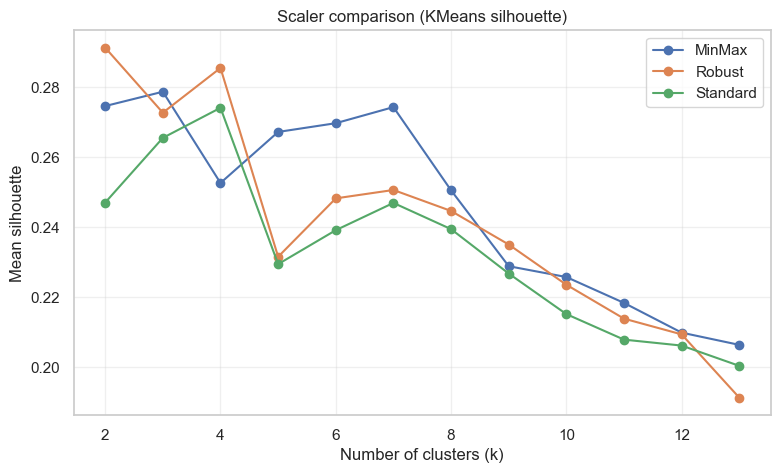

scaler,MinMax,Robust,Standard
k,,,
2,0.2746,0.2913,0.2470
3,0.2787,0.2727,0.2655
4,0.2526,0.2855,0.2741
5,0.2672,0.2315,0.2294
6,0.2697,0.2482,0.2391
7,0.2743,0.2506,0.2469
8,0.2505,0.2446,0.2394
9,0.2288,0.2350,0.2267
10,0.2257,0.2235,0.2151


In [44]:
scaler_scores = uc.compare_scalers(regular, inspect_cols, k_range=range(2, 14))
uc.plot_scaler_comparison(scaler_scores)
scaler_scores.pivot(index='k', columns='scaler', values='silhouette')

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Scaler selection interpretation.</b><br><br>
Both RobustScaler and MinMaxScaler were considered because the spend variables are skewed and measured on different scales. RobustScaler is usually safer when extreme observations remain in the modelling set, since it reduces the influence of unusually high values. However, in this project the most extreme customers are already held aside as outliers before fitting the final centroids. Under this cleaner modelling set, MinMaxScaler becomes a strong option because it places all clustering variables on the same 0-1 range while preserving their relative ordering.<br><br>
For the selected feature set and final <i>k = 8</i> configuration, MinMaxScaler kept the clusters cleaner and more interpretable than the alternatives tested. The resulting clusters still correspond to clear business groups. Therefore, MinMaxScaler is selected for the final model because it improves geometric separation without sacrificing interpretability.
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>A note on groceries.</b> Groceries are kept in the dataset for profiling because they are behaviourally important. However, groceries can dominate the distance calculation because most customers spend heavily there. For this reason, the candidate grid includes versions with and without <code>lifetime_spend_groceries</code>. If the without groceries option gives clearer personas, use it for KMeans and still use groceries afterwards to describe the segments.
</div>


### 3.2 — Inertia elbow

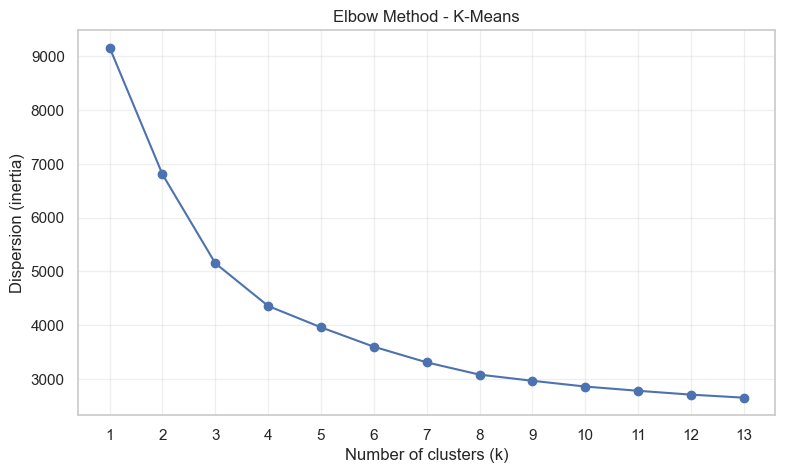

In [45]:
X_inspect = uc.apply_feature_pipeline(regular, inspect_cols, inspect_logabs,
                                      uc.get_scaler(INSPECT_SCALER), fit=True)
k_values, inertia = uc.kmeans_elbow(X_inspect, range(1, 14))
uc.plot_elbow(k_values, inertia)

### 3.3 — Ward dendrogram (on a sample)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
Agglomerative clustering is O(n²) in memory, so we draw the dendrogram on a random sample. Reading where long vertical links get cut suggests candidate values of k.
</div>

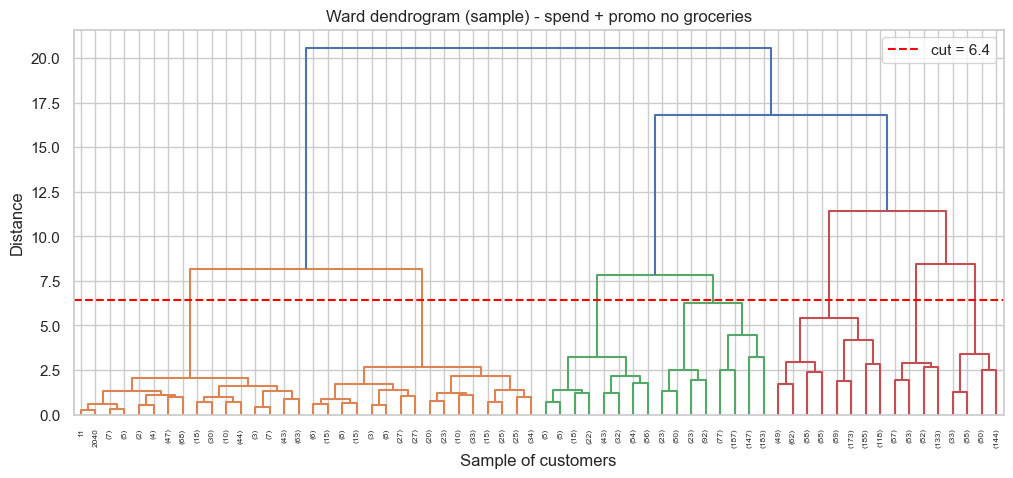

In [46]:
DENDRO_CUT_HEIGHT = 6.4

uc.plot_sample_dendrogram(
    X_inspect,
    title=f"Ward dendrogram (sample) - {INSPECT_SET}",
    linkage="ward",
    sample_size=3000,
    cut_height=DENDRO_CUT_HEIGHT,
    random_state=0,
)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Ward dendrogram interpretation.</b><br><br>
The Ward dendrogram is used as a visual diagnostic for compact, variance minimising group structure. Long vertical jumps indicate that relatively distant groups are being merged, so possible cut points should be considered just before those large jumps. In this dataset, the dendrogram suggests that there is meaningful hierarchical structure, but it does not provide a single unambiguous cut. Several values of <i>k</i> remain plausible, which is why the final number of clusters is not chosen from the dendrogram alone.<br><br>
Ward is nevertheless useful because it is conceptually aligned with KMeans: both favour compact groups under Euclidean geometry. Therefore, if Ward shows a broadly coherent structure, it supports the use of a based on centroids final model.
</div>


### 3.4 — Complete, average and single linkage dendrograms

Ward is usually the most compatible linkage with KMeans because both favour compact groups. Complete, average and single linkage are added as sensitivity checks: complete tends to form tighter clusters, average provides an intermediate linkage criterion, and single can reveal chaining/noise effects.


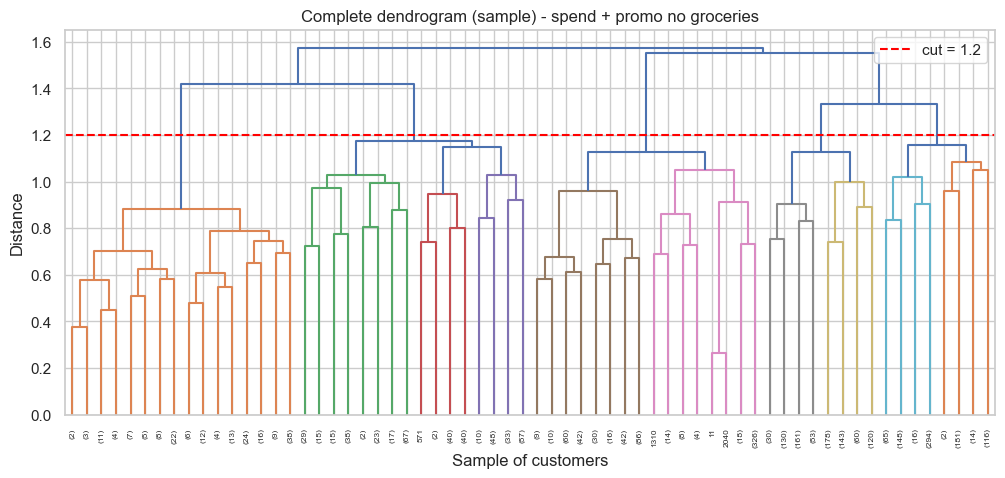

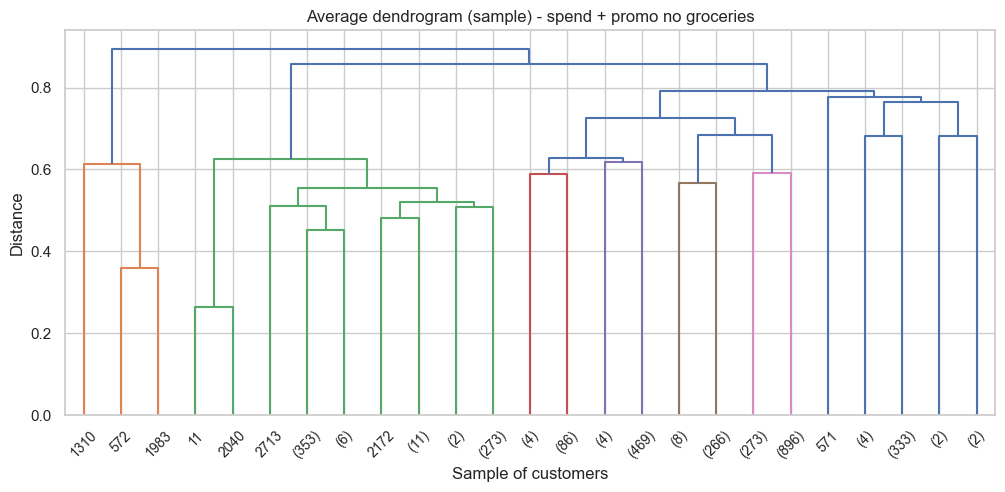

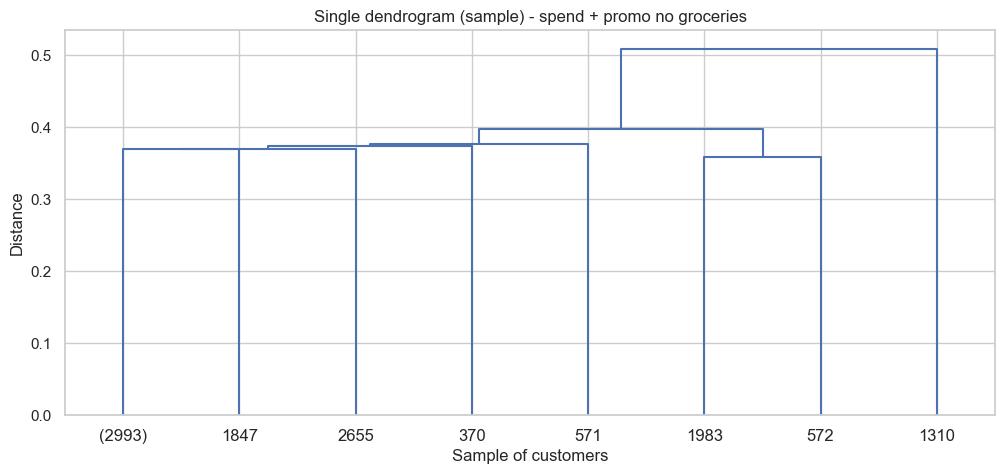

In [47]:
ALT_DENDRO_CUT_HEIGHTS = {
    "complete": 1.2,
    "average": None,
    "single": None,
}

uc.plot_alternative_dendrograms(
    X_inspect,
    title_suffix=INSPECT_SET,
    cut_heights=ALT_DENDRO_CUT_HEIGHTS,
    sample_size=3000,
    random_state=0,
)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Linkage comparison interpretation.</b><br><br>
The complete, average and single dendrograms are interpreted as sensitivity checks rather than competing final models.
<br><br>
<b>Complete linkage</b> tends to form compact and conservative clusters because it merges groups according to their farthest pairwise distance. If complete linkage shows large jumps, it suggests that some compact groups are clearly separated from the rest of the data.
<br><br>
<b>Average linkage</b> is less strict and merges clusters based on average distances between observations. It is useful as an intermediate check: when average linkage broadly agrees with Ward or complete linkage, the hierarchical structure is less dependent on one specific linkage rule.
<br><br>
<b>Single linkage</b> is the most sensitive to chaining effects, because clusters can be joined through narrow bridges of similar observations. If single linkage produces elongated chains or less clear cuts, this does not necessarily invalidate the segmentation; it indicates that some customers lie on behavioural gradients rather than in perfectly isolated groups.
<br><br>
Overall, the dendrograms support the idea that the data contains structure, but the cut point remains partly subjective. For this reason, the final solution is selected using the dendrograms together with silhouette, scaler comparison, ensemble stability and profiling interpretability.
</div>


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>4) Diagnostics B — feature set × k silhouette grid</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">After selecting the scaler and inspecting hierarchical structure, the silhouette grid is used to compare candidate feature spaces across several values of <i>k</i>. This provides a broader check that the final configuration is not chosen from a single diagnostic only.</p>
</div>


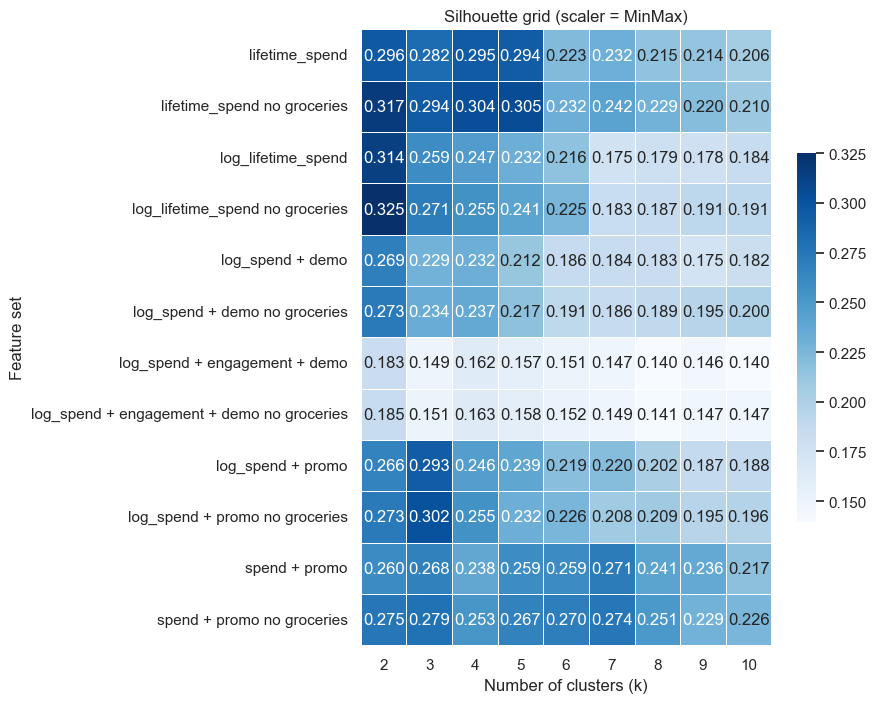

k,2,3,4,5,6,7,8,9,10
feature_set,,,,,,,,,
lifetime_spend,0.2958,0.2820,0.2948,0.2937,0.2228,0.2316,0.2154,0.2140,0.2059
lifetime_spend no groceries,0.3170,0.2944,0.3042,0.3051,0.2323,0.2419,0.2288,0.2196,0.2102
log_lifetime_spend,0.3141,0.2586,0.2474,0.2318,0.2160,0.1754,0.1787,0.1781,0.1838
log_lifetime_spend no groceries,0.3253,0.2707,0.2553,0.2409,0.2253,0.1834,0.1866,0.1913,0.1912
log_spend + demo,0.2687,0.2293,0.2320,0.2123,0.1862,0.1841,0.1830,0.1748,0.1818
log_spend + demo no groceries,0.2725,0.2335,0.2366,0.2168,0.1907,0.1860,0.1894,0.1950,0.2002
log_spend + engagement + demo,0.1830,0.1494,0.1619,0.1566,0.1507,0.1475,0.1395,0.1458,0.1398
log_spend + engagement + demo no groceries,0.1846,0.1507,0.1630,0.1579,0.1517,0.1489,0.1412,0.1468,0.1467
log_spend + promo,0.2662,0.2935,0.2457,0.2394,0.2190,0.2195,0.2022,0.1872,0.1883


In [48]:
grid = uc.silhouette_grid(regular, candidate_sets, k_range=range(2, 11),
                          scaler_name='MinMax')
grid_pivot = uc.plot_silhouette_grid(grid, title='Silhouette grid (scaler = MinMax)')
grid_pivot

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Interpretation.</b> Higher silhouette values indicate more compact and separated clusters for each candidate feature space. However, model selection also considers scaler behaviour, dendrogram structure, cluster size balance and business interpretability, since a mathematically strong solution is not necessarily the most useful segmentation.
</div>

<div style="background-color:#8F4A34; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #B2543D;">
<h2 style="color:#F3EEE6; margin:0;"><b>5) Model configuration</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The final configuration is chosen after the diagnostic stage. The objective is not to maximise one metric in isolation, but to select a solution that is quantitatively acceptable, stable and interpretable from a customer segmentation perspective.</p>
</div>


In [49]:
FEATURE_SET = "spend + promo no groceries"
SCALER      = "MinMax"
K           = 8

In [50]:
distance_cols, LOGABS = candidate_sets[FEATURE_SET]
profiling_cols = uc.get_profiling_features(regular, distance_cols)
scaler = uc.get_scaler(SCALER)
X = uc.apply_feature_pipeline(regular, distance_cols, LOGABS, scaler, fit=True)

print(f'Feature set : {FEATURE_SET}  ({len(distance_cols)} cols, log_abs={LOGABS})')
print(f'Scaler      : {SCALER}')
print(f'k           : {K}')
print(f'Matrix      : {X.shape}')

Feature set : spend + promo no groceries  (9 cols, log_abs=False)
Scaler      : MinMax
k           : 8
Matrix      : (32056, 9)


<div style="background-color:#8F4A34; color:#F3EEE6; padding:16px; border-radius:10px; border-left:8px solid #B2543D;">
<b>Decision log.</b><br><br>
The final model uses <i>spend + promo no groceries</i>, <i>MinMaxScaler</i> and <i>k = 8</i>.<br><br>
Groceries were left out of the clustering distance because they dominated several candidate solutions and made some groups look too similar. They are still used later in profiling, since grocery spend is important to understand customer value and regular household shopping.<br><br>
MinMax scaling was kept because the most extreme customers had already been separated before modelling, and the scaled variables became easier to compare. The promotion percentage was also checked separately; keeping it in the same pipeline did not change the final assignments because it was already in a 0 to 1 range.<br><br>
I also tested a more persona based option using promotion, category shares, age and number of children. It produced fewer negative silhouette values, but the UMAP separation was less clear and the clusters were less useful from a commercial point of view. For that reason, it was kept as a benchmark and not as the final model.<br><br>
I also tested solutions with smaller clusters and solutions with higher silhouette. They were not selected because the small clusters had too many negative silhouette values, or because the feature set became too narrow to support useful customer names. The final choice is therefore a compromise between clean clusters, visual separation and useful interpretation.
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>6) Model fitting and validation</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">KMeans is fitted using the selected configuration. The solution is then validated through cluster size distribution, silhouette analysis and two dimensional PCA/UMAP projections.</p>
</div>

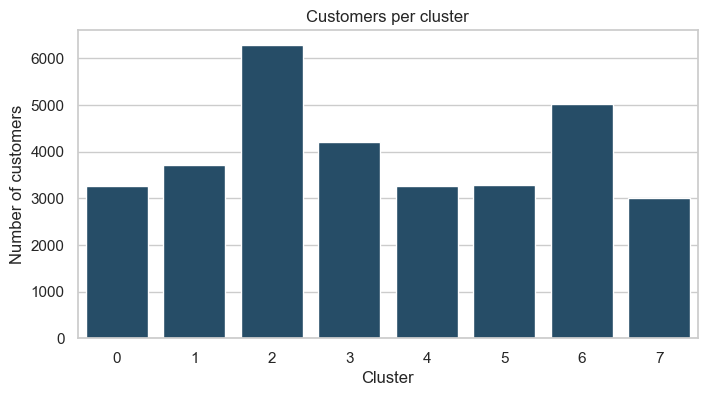

,customers,share_%
cluster,,
0,3264,10.2
1,3715,11.6
2,6288,19.6
3,4208,13.1
4,3264,10.2
5,3288,10.3
6,5018,15.7
7,3011,9.4


In [51]:
kmeans = uc.fit_kmeans(X, K)
regular['cluster'] = kmeans.labels_
uc.plot_cluster_sizes(regular, 'cluster')
uc.cluster_sizes(regular, 'cluster')

### 6.1 — Silhouette plot

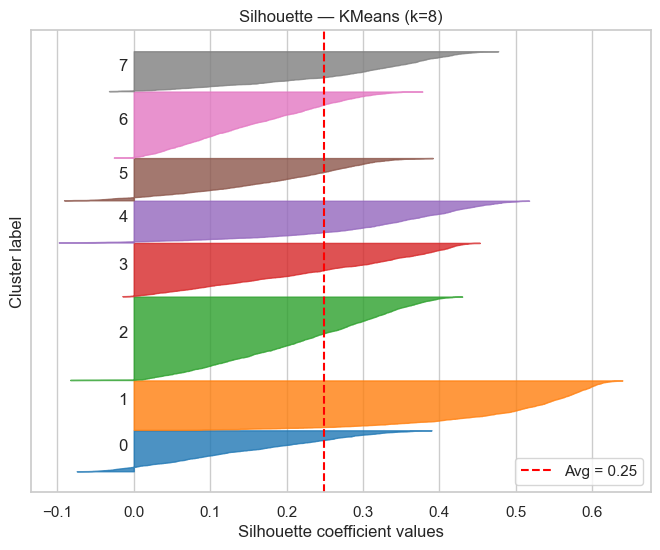

Average silhouette: 0.249


In [52]:
avg_sil = uc.plot_silhouette_blades(X, kmeans.labels_, title=f'Silhouette — KMeans (k={K})')
print('Average silhouette:', round(avg_sil, 3))

### 6.2 — PCA and UMAP projections

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
PCA and UMAP are used as two dimensional projections for visual inspection. A subsample is used to keep the visualisation computationally efficient.
</div>

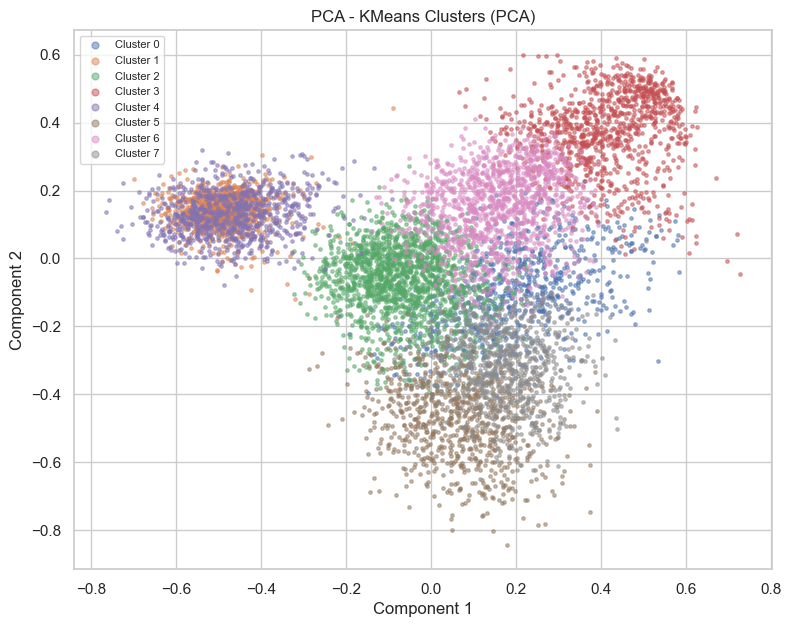

In [53]:
X_emb, lab_emb = uc.subsample(X, kmeans.labels_, n=8000)
pca_emb = uc.embed_pca(X_emb)
uc.plot_embedding(pca_emb, lab_emb, title='PCA - KMeans Clusters', method_name='PCA')

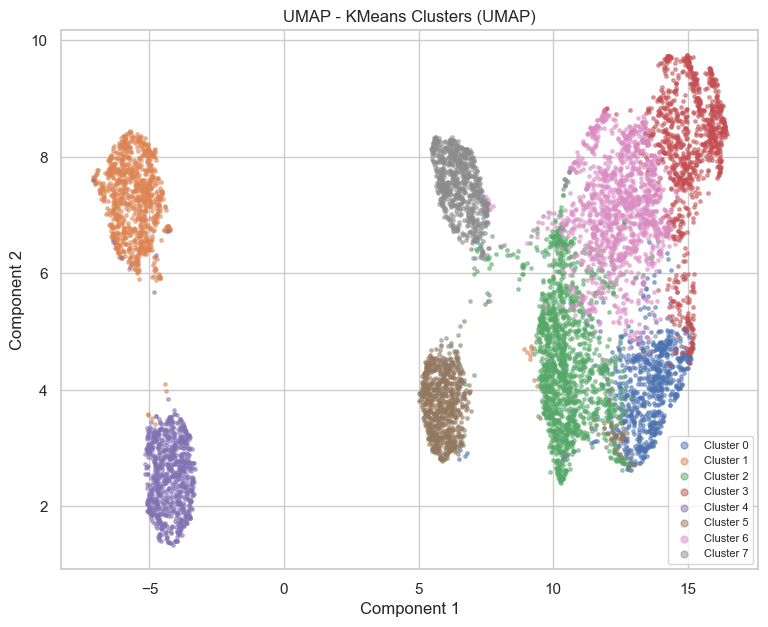

In [54]:
umap_emb, method = uc.embed_umap(X_emb)
uc.plot_embedding(umap_emb, lab_emb, title='UMAP - KMeans Clusters', method_name=method)

### 6.3 — Embedded feature importance check (validates the feature set)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The correlation matrix in Notebook&nbsp;1 is a <b>filter</b> method: it only removes <i>redundant</i> features and cannot say which features actually <i>drive</i> the segments. Here we add an <b>embedded</b> method &mdash; an L1-penalised (Lasso) logistic model and a Random Forest &mdash; using the cluster label as a proxy target. The L1 penalty shrinks uninformative coefficients to exactly zero (an embedded selection), and both models rank how much each feature contributes to telling the segments apart. A peaked, sparse ranking means the segmentation rests on a few interpretable drivers. This is a after the model validation of the feature set chosen in Section&nbsp;5, not a selection before modelling step.
</div>

,lasso_importance,lasso_selected,forest_importance
feature,,,
percentage_of_products_bought_promotion,0.2119,True,0.2801
lifetime_spend_hygiene,0.1247,True,0.1317
lifetime_spend_fish,0.1154,True,0.0657
lifetime_spend_nonalcohol_drinks,0.1131,True,0.0735
lifetime_spend_vegetables,0.1044,True,0.1113
lifetime_spend_meat,0.1030,True,0.1092
lifetime_spend_alcohol_drinks,0.0965,True,0.0785
lifetime_spend_technology,0.0829,True,0.1253
lifetime_spend_petfood,0.0481,True,0.0247


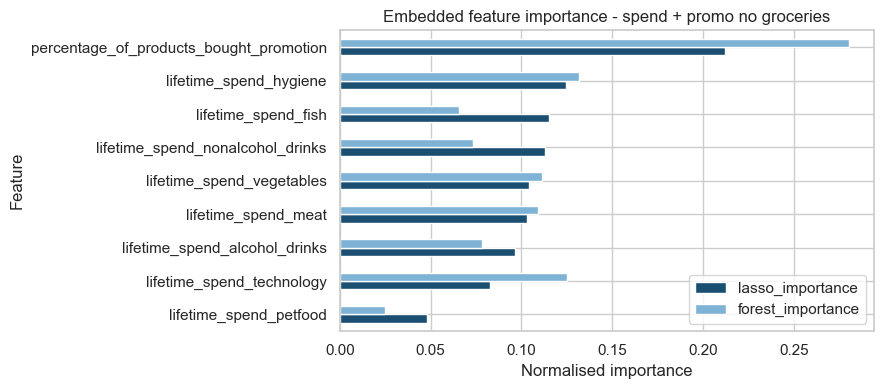

Embedded shortlist (forest importance > median): ['percentage_of_products_bought_promotion', 'lifetime_spend_hygiene', 'lifetime_spend_vegetables', 'lifetime_spend_technology']


In [55]:
emb_importance = uc.embedded_feature_importance(
    X, kmeans.labels_, distance_cols, method='both', random_state=0
)
display(emb_importance)
uc.plot_embedded_importance(emb_importance,
                            title=f'Embedded feature importance - {FEATURE_SET}')

print('Embedded shortlist (forest importance > median):',
      uc.select_features_embedded(emb_importance, 'forest_importance'))

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>7) Method benchmarks before ensemble</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">The selected KMeans solution is compared with alternative clustering assumptions before the stability step. These checks are not meant to replace the final model automatically. They are used to verify whether the same customer structure remains plausible under hierarchical, density based and topology based views.</p>
</div>

### 7.0 — Independent method search

Each clustering family is first evaluated on its own candidate range. This avoids assuming that every method should return the same number of clusters. The comparison is used to understand the trade off between separation, cluster balance and interpretability before selecting the final operational solution.

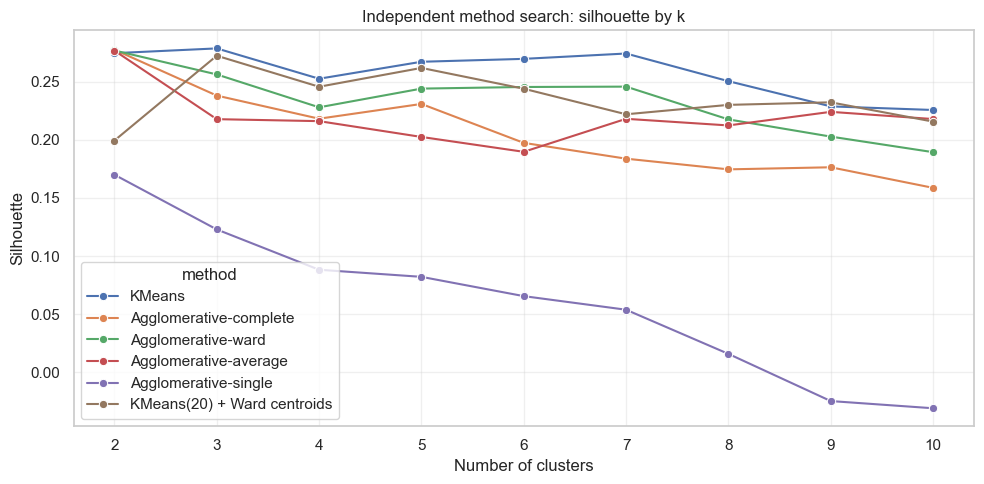

,method,k,silhouette,min_cluster_size,max_cluster_size,largest_share_%
0,KMeans,3,0.2787,7185,15685,48.9
1,Agglomerative-complete,2,0.2776,1118,3882,77.6
2,Agglomerative-ward,2,0.2769,1115,3885,77.7
3,Agglomerative-average,2,0.2768,1118,3882,77.6
4,KMeans,2,0.2746,7346,24710,77.1
5,KMeans,7,0.2743,3046,8481,26.5
6,KMeans(20) + Ward centroids,3,0.2724,6950,16247,50.7
7,KMeans(20) + Ward centroids,5,0.2619,2940,10183,31.8
8,KMeans(20) + Ward centroids,4,0.2457,6064,10183,31.8


KMeans candidates


,method,k,silhouette,min_cluster_size,max_cluster_size,largest_share_%
1,KMeans,3,0.2787,7185,15685,48.9
0,KMeans,2,0.2746,7346,24710,77.1
5,KMeans,7,0.2743,3046,8481,26.5
4,KMeans,6,0.2697,3014,8915,27.8
3,KMeans,5,0.2672,3015,8964,28.0


Best hierarchical candidates


,method,linkage,k,sample_size,silhouette,r2,min_cluster_size,max_cluster_size,largest_share_%
0,Agglomerative-complete,complete,2,5000,0.2776,0.2542,1118,3882,77.6
1,Agglomerative-ward,ward,2,5000,0.2769,0.2534,1115,3885,77.7
2,Agglomerative-average,average,2,5000,0.2768,0.2536,1118,3882,77.6
3,Agglomerative-ward,ward,3,5000,0.2563,0.4095,1115,2190,43.8
4,Agglomerative-ward,ward,7,5000,0.2458,0.6068,441,1254,25.1


Best centroid Ward candidates


,method,k,micro_k,silhouette,r2,min_cluster_size,max_cluster_size,largest_share_%
1,KMeans(20) + Ward centroids,3,20,0.2724,0.4309,6950,16247,50.7
3,KMeans(20) + Ward centroids,5,20,0.2619,0.5465,2940,10183,31.8
2,KMeans(20) + Ward centroids,4,20,0.2457,0.5058,6064,10183,31.8
4,KMeans(20) + Ward centroids,6,20,0.2440,0.5833,2940,8859,27.6
7,KMeans(20) + Ward centroids,9,20,0.2323,0.6652,923,6340,19.8


In [56]:
K_SEARCH_RANGE = range(2, 11)

method_benchmarks = uc.run_method_benchmarks(
    X,
    k_range=K_SEARCH_RANGE,
    random_state=0,
)

uc.display_method_benchmarks(method_benchmarks)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Benchmark interpretation.</b><br><br>
The benchmark table is intentionally separated by method family, because each algorithm reports a different set of diagnostics. KMeans is evaluated mainly through silhouette and cluster balance; hierarchical clustering adds a variance explained measure; centroid Ward uses an intermediate set of KMeans micro clusters. Keeping the tables separate avoids empty columns and makes the comparison easier to read.
<br><br>
The final model is not selected by the highest silhouette alone. A solution is only retained if it is also stable, visually coherent in the UMAP projection, reasonably balanced in size and interpretable when compared with the full customer profile.
</div>

In [57]:
ward_sample_idx, ward_labels = uc.fit_hierarchical_sample(
    X,
    K,
    sample_size=5000,
    linkage="ward",
    random_state=0,
)
display(uc.compare_solutions(
    kmeans.labels_[ward_sample_idx],
    ward_labels,
    name_a="KMeans",
    name_b="Ward",
))

,Ward 0,Ward 1,Ward 2,Ward 3,Ward 4,Ward 5,Ward 6,Ward 7
KMeans 0,127,3,336,24,4,0,2,2
KMeans 1,3,0,0,0,0,586,9,1
KMeans 2,921,21,9,34,8,1,1,0
KMeans 3,0,3,67,52,0,0,0,486
KMeans 4,4,0,0,0,0,12,504,0
KMeans 5,48,11,5,0,475,0,0,0
KMeans 6,84,8,19,542,0,0,0,113
KMeans 7,31,429,5,0,10,0,0,0


### 7.1 — Ward vs complete vs average vs single sample comparison

This fits agglomerative clustering on the same sample with four linkages. It does not replace the final KMeans model; it checks whether the broad structure is stable under different hierarchical assumptions.


In [58]:
hierarchical_comparison, hierarchical_solution_tables = uc.compare_hierarchical_linkages(
    X,
    K,
    kmeans.labels_,
    sample_size=5000,
    random_state=0,
)

display(hierarchical_comparison)

for linkage_name, comparison_table in hierarchical_solution_tables.items():
    print(f"KMeans vs Agglomerative-{linkage_name}")
    display(comparison_table)

,method,sample_size,k,silhouette_sample
0,Agglomerative-ward,5000,8,0.2176
1,Agglomerative-complete,5000,8,0.1746
2,Agglomerative-average,5000,8,0.2124
3,Agglomerative-single,5000,8,0.0158


KMeans vs Agglomerative-ward


,Ward 0,Ward 1,Ward 2,Ward 3,Ward 4,Ward 5,Ward 6,Ward 7
KMeans 0,127,3,336,24,4,0,2,2
KMeans 1,3,0,0,0,0,586,9,1
KMeans 2,921,21,9,34,8,1,1,0
KMeans 3,0,3,67,52,0,0,0,486
KMeans 4,4,0,0,0,0,12,504,0
KMeans 5,48,11,5,0,475,0,0,0
KMeans 6,84,8,19,542,0,0,0,113
KMeans 7,31,429,5,0,10,0,0,0


KMeans vs Agglomerative-complete


,Complete 0,Complete 1,Complete 2,Complete 3,Complete 4,Complete 5,Complete 6,Complete 7
KMeans 0,0,1,166,59,9,14,135,114
KMeans 1,596,0,1,2,0,0,0,0
KMeans 2,4,5,1,861,1,9,84,30
KMeans 3,0,1,540,0,0,0,67,0
KMeans 4,518,0,0,2,0,0,0,0
KMeans 5,0,9,0,61,434,0,0,35
KMeans 6,0,5,155,59,0,19,528,0
KMeans 7,0,405,0,51,2,1,12,4


KMeans vs Agglomerative-average


,Average 0,Average 1,Average 2,Average 3,Average 4,Average 5,Average 6,Average 7
KMeans 0,185,7,2,1,0,0,301,2
KMeans 1,2,0,0,596,0,0,1,0
KMeans 2,920,9,0,4,1,0,61,0
KMeans 3,0,0,0,0,0,1,607,0
KMeans 4,4,1,0,515,0,0,0,0
KMeans 5,48,485,2,0,3,0,1,0
KMeans 6,70,0,0,2,0,1,693,0
KMeans 7,463,8,0,0,0,1,3,0


KMeans vs Agglomerative-single


,Single 0,Single 1,Single 2,Single 3,Single 4,Single 5,Single 6,Single 7
KMeans 0,497,1,0,0,0,0,0,0
KMeans 1,599,0,0,0,0,0,0,0
KMeans 2,995,0,0,0,0,0,0,0
KMeans 3,606,0,0,0,0,1,1,0
KMeans 4,520,0,0,0,0,0,0,0
KMeans 5,537,0,1,0,1,0,0,0
KMeans 6,765,0,0,0,0,0,0,1
KMeans 7,474,0,0,1,0,0,0,0


### 7.1.1 — Tracking benchmark labels

Some clustering workflows store every attempted solution as a separate column, such as `st_ward5`, `mm_ward9` or `rb_kmeans6`. In this notebook, the same idea is applied more selectively. Full data labels are stored when they are used later for profiling, export or comparison. Direct agglomerative labels are computed on a sample because full hierarchical clustering has quadratic memory cost and is used here as a benchmark rather than as the final assignment method.


In [59]:
label_tracking = uc.benchmark_label_tracking()
display(label_tracking)

,solution,label_column,scope,purpose
0,Final KMeans,cluster,regular customer dataset,final assignment before outlier reintegration
1,Agglomerative linkages,hierarchical comparison tables,sample only,benchmark against KMeans under several linkages
2,Centroid Ward macro clusters,macro_cluster,regular customer dataset,two stage hierarchical benchmark
3,DBSCAN,dbscan_cluster if enabled,benchmark only,density and noise sensitivity check
4,SOM,som_unit,regular customer dataset,topology based visual profiling


### 7.2 — Hierarchical R2 comparison

The R2-like metric compares how much of the total variance is explained by the cluster separation for each hierarchical linkage and number of clusters. It is used as an additional diagnostic alongside silhouette and dendrogram inspection.


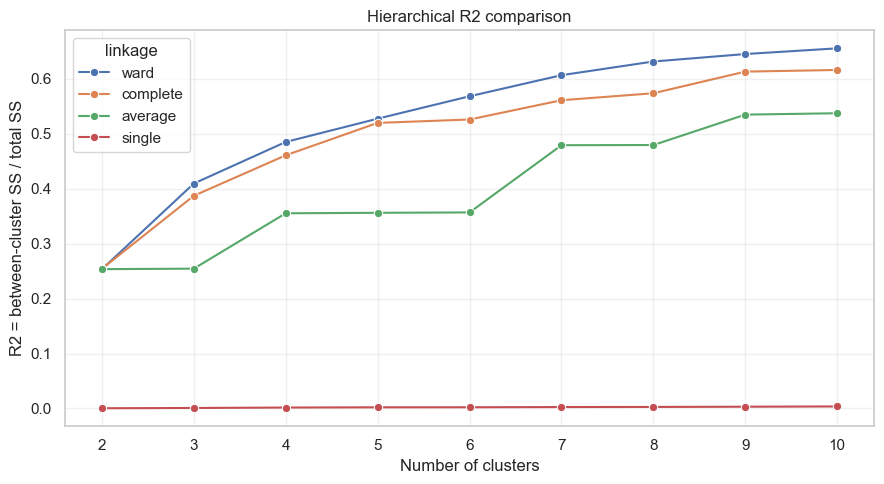

linkage,average,complete,single,ward
k,,,,
2,0.2536,0.2542,0.0003,0.2534
3,0.2545,0.3872,0.0008,0.4095
4,0.3553,0.4609,0.0016,0.4852
5,0.3562,0.5199,0.0020,0.5276
6,0.3569,0.5261,0.0021,0.5684
7,0.4793,0.5612,0.0025,0.6068
8,0.4796,0.5739,0.0027,0.6317
9,0.5350,0.6133,0.0031,0.6453
10,0.5375,0.6163,0.0036,0.6557


In [60]:
hierarchical_r2 = uc.hierarchical_r2_grid(
    X,
    k_range=range(2, 11),
    linkages=["ward", "complete", "average", "single"],
    sample_size=5000,
    random_state=0,
)

uc.plot_hierarchical_r2(hierarchical_r2)
display(hierarchical_r2.pivot(index="k", columns="linkage", values="r2"))


### 7.3 — Hierarchical on KMeans centroids
This benchmark uses a two stage strategy. First, <b>20 KMeans small clusters</b> are created to summarise the detailed structure of the customer space. Second, Ward hierarchical clustering groups those centroids into the final larger segments. Keeping <code>MICRO_K = 20</code> makes the intermediate representation granular enough to reveal local structure, while still small enough to inspect with a dendrogram.


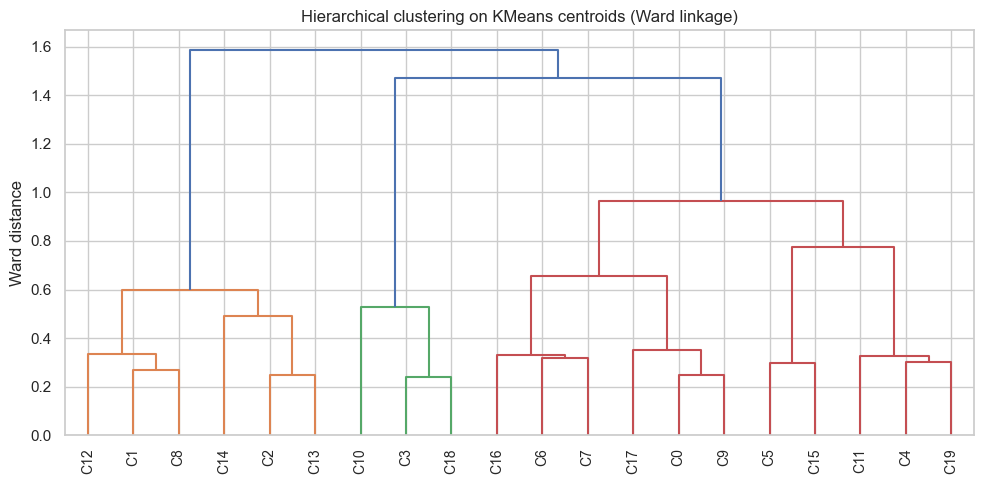

Micro-cluster sizes


micro_cluster
0     2420
1     1850
2     1570
3     1706
4      898
5     1449
6     1324
7     1221
8     1759
9     2147
10    3651
11     984
12    1210
13    1547
14     923
15    1675
16    1298
17    1773
18    1593
19    1058
Name: count, dtype: int64

Macro-cluster sizes


macro_cluster
0    4819
1    4040
2    3299
3    3651
4    3843
5    6340
6    3124
7    2940
Name: count, dtype: int64

,solution,silhouette
0,Final KMeans,0.2508
1,Centroid Ward macro,0.2303


In [61]:
MICRO_K = 20
micro_kmeans, centroids_df, Z = uc.apply_centroid_ward_macro(
    regular,
    X,
    distance_cols,
    K,
    micro_k=MICRO_K,
    random_state=0,
)

,Centroid Ward macro 0,Centroid Ward macro 1,Centroid Ward macro 2,Centroid Ward macro 3,Centroid Ward macro 4,Centroid Ward macro 5,Centroid Ward macro 6,Centroid Ward macro 7
Final KMeans 0,48,561,0,0,2612,8,11,24
Final KMeans 1,2,0,48,3646,0,18,0,1
Final KMeans 2,188,0,0,1,668,5347,81,3
Final KMeans 3,720,3476,0,0,12,0,0,0
Final KMeans 4,1,0,3250,4,8,1,0,0
Final KMeans 5,0,0,0,0,330,2,59,2897
Final KMeans 6,3858,3,1,0,178,941,36,1
Final KMeans 7,2,0,0,0,35,23,2937,14


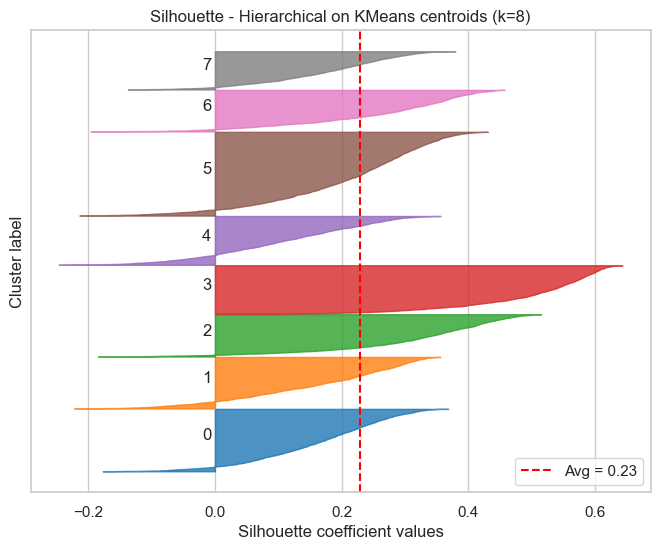

0.22911390698850337

In [62]:
macro_comparison = uc.compare_solutions(
    regular["cluster"].values,
    regular["macro_cluster"].values,
    name_a="Final KMeans",
    name_b="Centroid Ward macro",
)
display(macro_comparison)

uc.plot_silhouette_blades(
    X,
    regular["macro_cluster"].values,
    title=f"Silhouette - Hierarchical on KMeans centroids (k={K})",
)

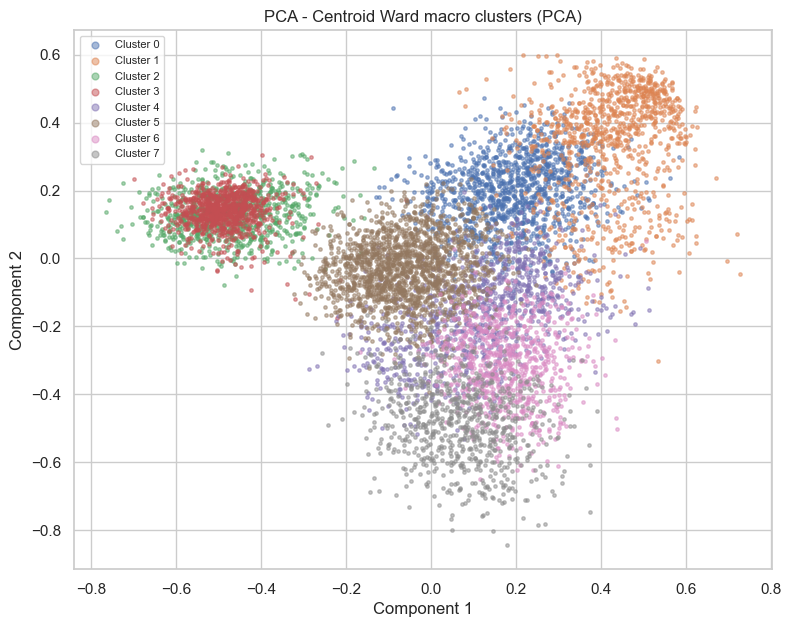

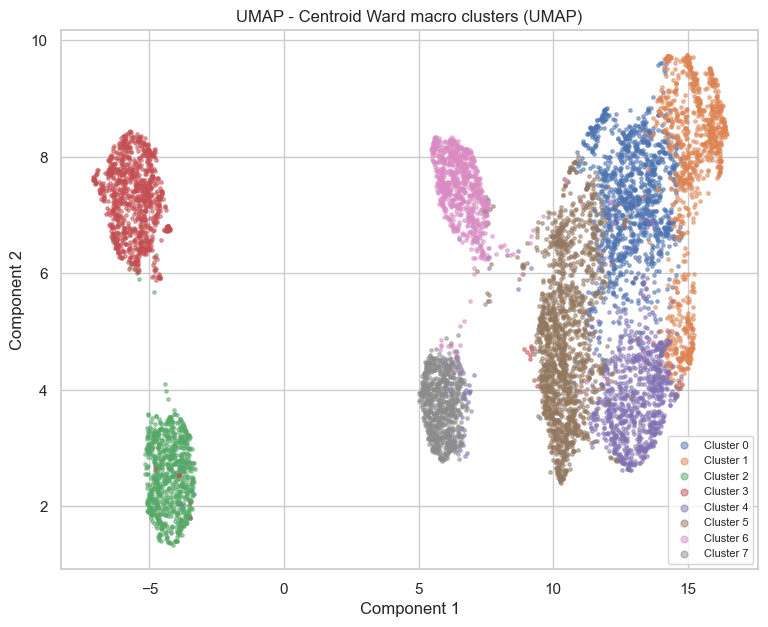

In [63]:
uc.plot_macro_embeddings(
    X,
    regular["macro_cluster"].values,
    sample_size=8000,
    random_state=0,
)

### 7.4 — DBSCAN density benchmark

DBSCAN is used as a density based benchmark. In this dataset it is useful to test whether there are dense pockets of customers, but it is not expected to be the final segmentation method because high dimensional spend data often leads to either one large cluster or a high proportion of noise points. When DBSCAN returns fewer than two non noise clusters, a silhouette value is not mathematically defined, so those parameter settings are excluded from the clean results table.

In [64]:
dbscan_results, valid_dbscan, invalid_dbscan = uc.dbscan_benchmark_table(
    X,
    eps_values=[0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 2.0],
    min_samples_values=[5, 10, 20, 40],
    sample_size=8000,
    random_state=0,
)

if valid_dbscan.empty:
    print("No DBSCAN setting produced enough non-noise clusters for silhouette.")
else:
    display(valid_dbscan.head(10))

print("Parameter settings with one cluster or no valid silhouette")
display(invalid_dbscan.head(10))

No DBSCAN setting produced enough non-noise clusters for silhouette.
Parameter settings with one cluster or no valid silhouette


,eps,min_samples,n_clusters,noise_pct
0,0.5,5,1,0.0
1,0.5,10,1,0.0
2,0.5,20,1,0.0
3,0.5,40,1,0.0
4,0.7,5,1,0.0
5,0.7,10,1,0.0
6,0.7,20,1,0.0
7,0.7,40,1,0.0
8,0.9,5,1,0.0
9,0.9,10,1,0.0


In [65]:
RUN_DBSCAN = False
DBSCAN_EPS = 0.9
DBSCAN_MIN_SAMPLES = 10

dbscan_labels = uc.maybe_fit_dbscan(
    X,
    run=RUN_DBSCAN,
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
)

if dbscan_labels is not None:
    regular["dbscan_cluster"] = dbscan_labels

DBSCAN is kept as a benchmark only. The final assignment is not based on DBSCAN labels.


### 7.5 — SOM Map feature map analysis

A SOM Map is used as an exploratory validation tool rather than as the final clustering algorithm. A medium sized grid is used so that neighbourhood patterns remain visible without creating hundreds of almost empty units. The hit map shows where customers concentrate, the U Matrix highlights stronger separations between neighbouring units, and the feature maps show how the main variables vary across the same customer space.

,iteration,quantization_error
0,50,0.3368
1,100,0.3460
2,200,0.3571
3,400,0.3472
4,700,0.3332
5,1000,0.3281


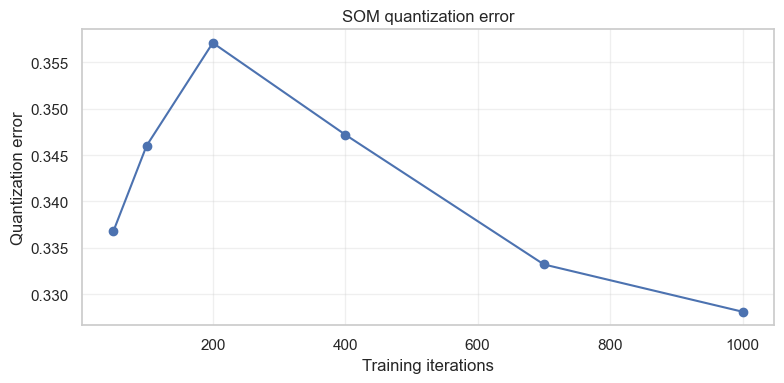

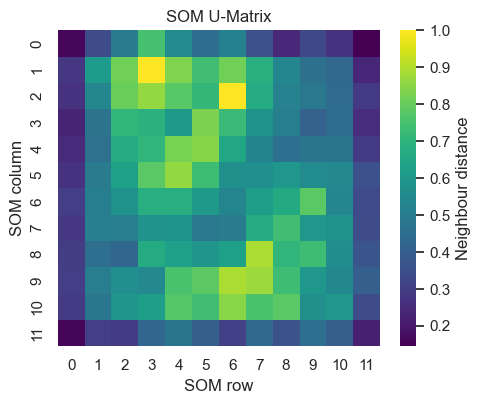

In [66]:
SOM_GRID = (12, 12)
SOM_ITERATIONS = 1000

som_cols, X_som, som_curve, som_model = uc.run_som_diagnostic(
    regular,
    scaler_name=SCALER,
    grid=SOM_GRID,
    iterations=SOM_ITERATIONS,
    sample_size=12000,
    random_state=0,
)

Active SOM units: 144 out of 144


,customers
66,748
131,698
114,649
82,630
108,627
40,616
8,613
116,538
143,536
83,521


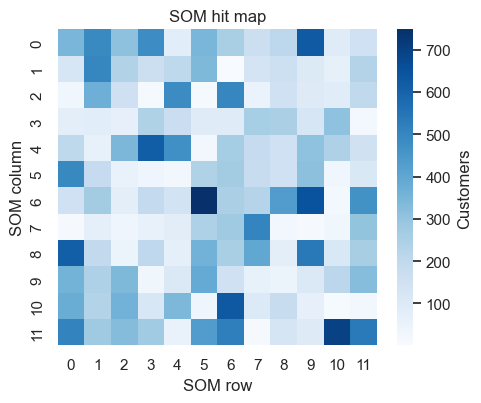

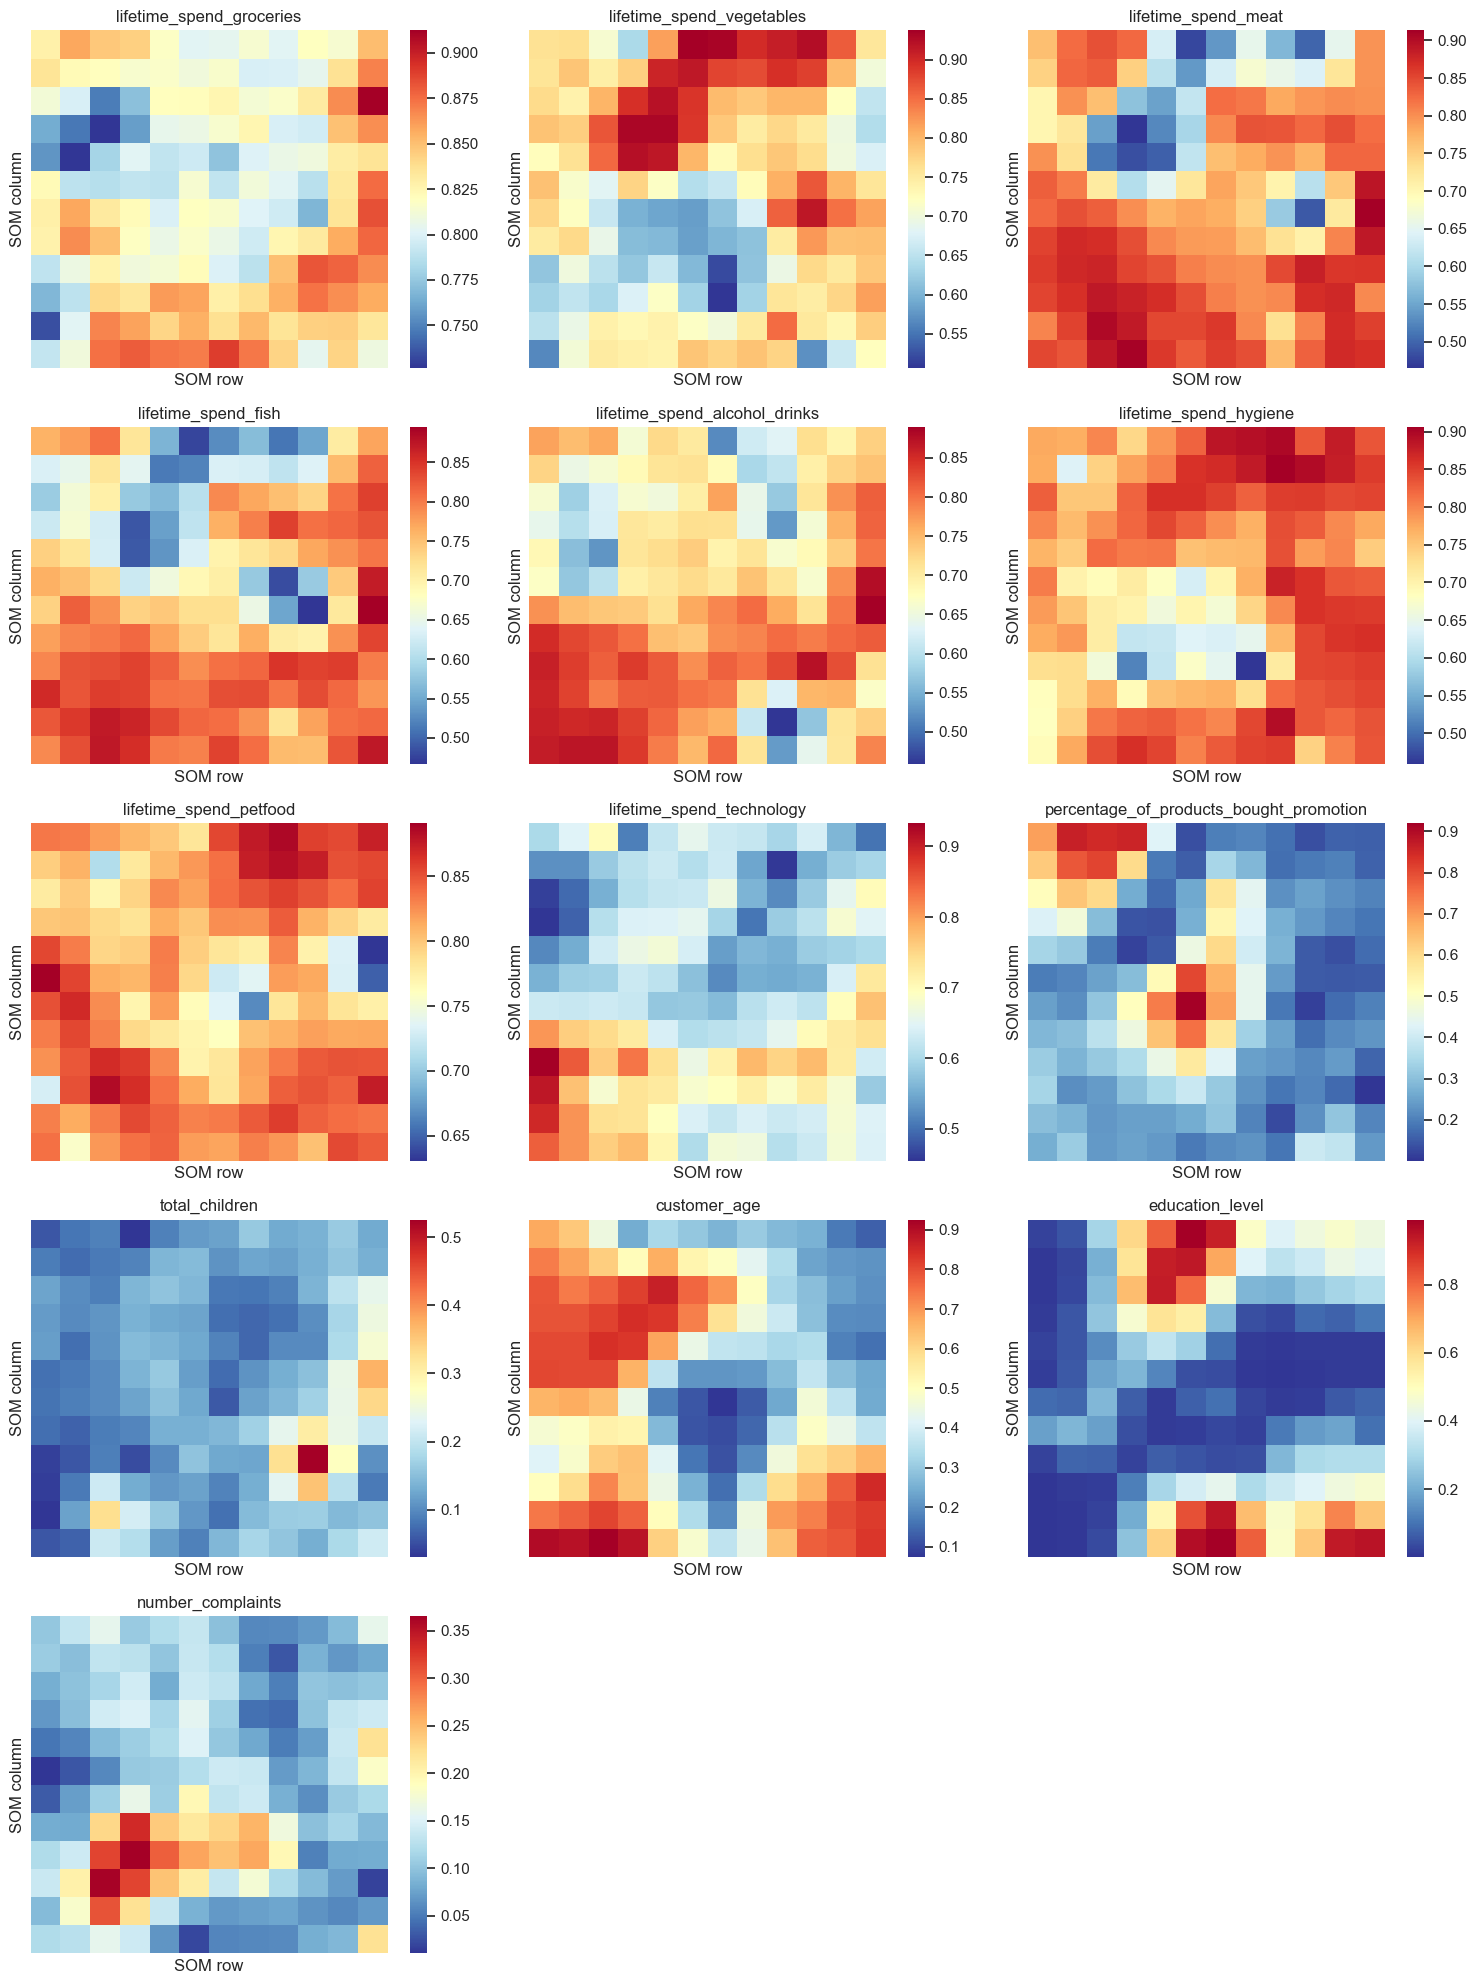

In [67]:
regular["som_unit"] = uc.assign_and_plot_som(
    regular,
    som_model,
    X_som,
    som_cols,
    grid=SOM_GRID,
)

### 7.5.1 — SOM interpretation

The SOM is used as visual support for the final segmentation. It helps check whether related variables occupy coherent regions of the same customer map.

The main aspects inspected are vegetables and hygiene for the wellness profile, technology for the technology oriented segment, promotion usage for the discount oriented segment, household variables for the family segment and complaints for service sensitivity.

Because the SOM does not optimise the same objective as KMeans, it is not used to assign final labels. It remains an exploratory diagnostic that supports the profiling stage.

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>8) Ensemble / consensus clustering</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">After comparing the individual clustering methods, a consensus KMeans procedure is used to measure stability. The same configuration is fitted several times with different random states; each customer receives the label that appears most consistently. High agreement between the single run and the consensus solution supports the final model as stable rather than accidental.</p>
</div>

Single-run silhouette  : 0.2505
Consensus  silhouette  : 0.2505
Agreement single vs consensus (ARI): 0.9969
Mean stability: 0.999 | very stable (>=0.9): 99.7% | ambiguous (<0.6): 0.0%


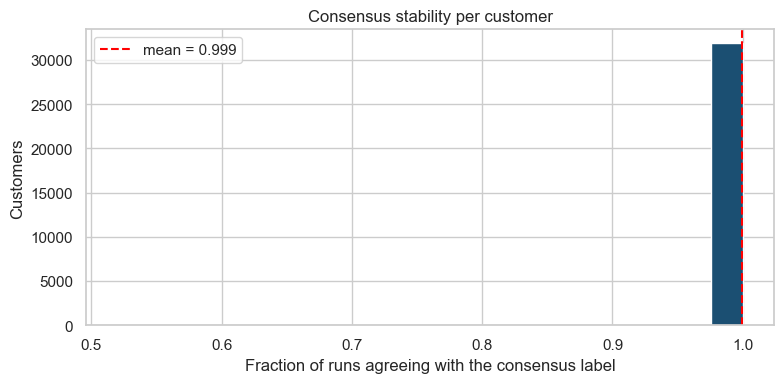

In [68]:
consensus_labels, stability = uc.consensus_report(
    X,
    kmeans.labels_,
    K,
    n_runs=25,
    random_state=0,
)
regular["cluster_stability"] = stability

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>9) Segment profiling</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Cluster interpretation is performed after fitting the model. The profiling tables compare each segment with the overall customer base using spend, demographic, engagement, location and complaint variables. This avoids naming clusters only from the distance variables and produces more distinctive business labels.</p>
</div>


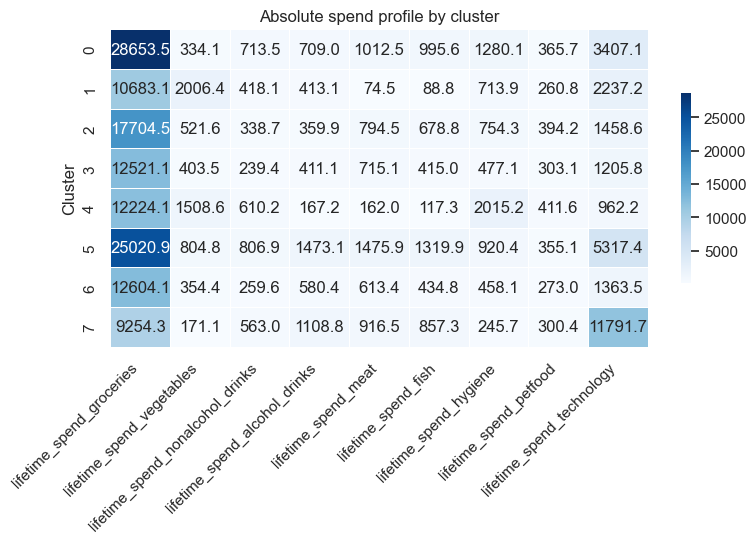

,lifetime_spend_groceries,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_spend_technology
cluster,,,,,,,,,
0,28653.54,334.14,713.54,709.00,1012.49,995.64,1280.14,365.73,3407.12
1,10683.12,2006.37,418.13,413.10,74.48,88.83,713.92,260.76,2237.16
2,17704.50,521.64,338.74,359.88,794.49,678.84,754.30,394.18,1458.58
3,12521.14,403.52,239.45,411.14,715.10,415.03,477.12,303.13,1205.81
4,12224.10,1508.63,610.23,167.16,162.00,117.27,2015.23,411.55,962.20
5,25020.86,804.75,806.94,1473.09,1475.91,1319.89,920.37,355.09,5317.39
6,12604.12,354.39,259.63,580.44,613.42,434.75,458.06,272.98,1363.54
7,9254.27,171.09,562.95,1108.78,916.50,857.34,245.74,300.42,11791.71
OVERALL,15925.51,729.54,457.41,607.75,711.43,595.22,818.06,333.85,3015.00


In [69]:
spend_cols = [c for c in regular.columns if c.startswith('lifetime_spend_')]
spend_profile = uc.profile_clusters(regular, 'cluster', spend_cols)
uc.plot_profile_heatmap(spend_profile, 'Absolute spend profile by cluster')
spend_profile


### 9.1 — Petfood signal check

Petfood spending is checked separately because one previous naming option considered a focused on petfood segment. A segment should only be named after petfood if the category is clearly distinctive, either in absolute spend or as a relevant share of its total basket.


In [70]:
if "lifetime_spend_petfood" in spend_profile.columns:
    pet_check = spend_profile.drop(index="OVERALL", errors="ignore").copy()
    pet_spend_cols = [c for c in pet_check.columns if c.startswith("lifetime_spend_")]
    pet_check["petfood_share_%"] = (
        pet_check["lifetime_spend_petfood"] / pet_check[pet_spend_cols].sum(axis=1) * 100
    )
    pet_check = pet_check[["lifetime_spend_petfood", "petfood_share_%"]].round(2)
    display(pet_check.sort_values("lifetime_spend_petfood", ascending=False))

    print("Highest absolute petfood cluster:", pet_check["lifetime_spend_petfood"].idxmax())
    print("Highest petfood share cluster:", pet_check["petfood_share_%"].idxmax())


,lifetime_spend_petfood,petfood_share_%
cluster,,
4,411.55,2.26
2,394.18,1.71
0,365.73,0.98
5,355.09,0.95
3,303.13,1.82
7,300.42,1.19
6,272.98,1.61
1,260.76,1.54


Highest absolute petfood cluster: 4
Highest petfood share cluster: 4


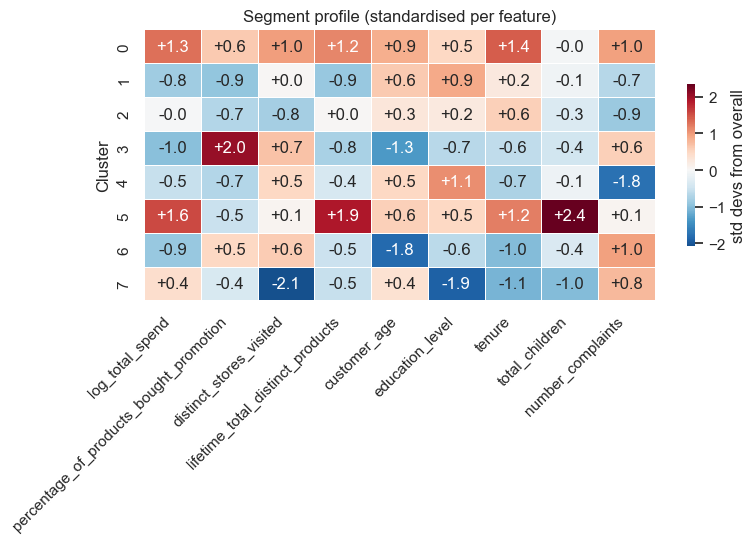

,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,customer_age,education_level,tenure,total_children,number_complaints
cluster,,,,,,,,,
0,1.30,0.62,0.98,1.15,0.85,0.49,1.42,-0.04,0.95
1,-0.83,-0.92,0.03,-0.88,0.62,0.89,0.25,-0.09,-0.67
2,-0.03,-0.68,-0.80,0.03,0.28,0.23,0.57,-0.33,-0.87
3,-0.97,2.04,0.69,-0.78,-1.34,-0.65,-0.60,-0.43,0.56
4,-0.54,-0.68,0.49,-0.38,0.49,1.09,-0.74,-0.11,-1.76
5,1.56,-0.52,0.07,1.90,0.56,0.50,1.21,2.36,0.07
6,-0.89,0.50,0.61,-0.51,-1.82,-0.63,-1.01,-0.36,0.95
7,0.41,-0.37,-2.07,-0.54,0.36,-1.91,-1.10,-1.01,0.76


In [71]:
key_cols = [c for c in [
    "log_total_spend", "percentage_of_products_bought_promotion",
    "distinct_stores_visited", "lifetime_total_distinct_products",
    "customer_age", "education_level", "tenure", "total_children",
    "number_complaints",
] if c in regular.columns]

mixed_profile = uc.profile_clusters(regular, "cluster", key_cols)
uc.plot_profile_heatmap_z(mixed_profile,
                          title="Segment profile (standardised per feature)")

### 9.2 — Segment separation plots

The following plots summarise the same profiling logic in a more visual way. The scaled mean comparison highlights which clusters are highest or lowest on each variable, while the boxplots show whether the separation is concentrated around the median or driven mainly by extreme customers.


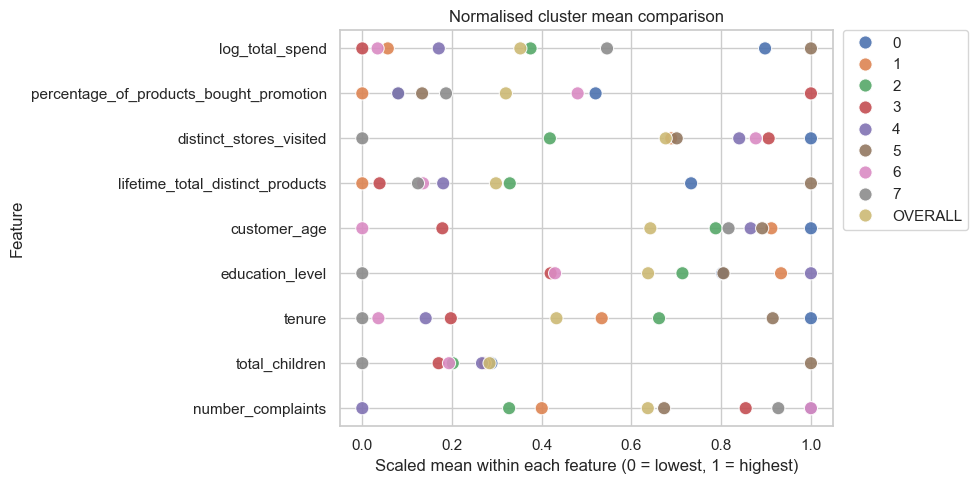

,log_total_spend,percentage_of_products_bought_promotion,distinct_stores_visited,lifetime_total_distinct_products,customer_age,education_level,tenure,total_children,number_complaints
cluster,,,,,,,,,
0,0.90,0.52,1.00,0.73,1.00,0.80,1.00,0.29,1.00
1,0.06,0.00,0.69,0.00,0.91,0.93,0.53,0.27,0.40
2,0.38,0.08,0.42,0.33,0.79,0.71,0.66,0.20,0.33
3,0.00,1.00,0.91,0.04,0.18,0.42,0.20,0.17,0.85
4,0.17,0.08,0.84,0.18,0.87,1.00,0.14,0.27,0.00
5,1.00,0.13,0.70,1.00,0.89,0.80,0.91,1.00,0.67
6,0.03,0.48,0.88,0.14,0.00,0.43,0.04,0.19,1.00
7,0.55,0.19,0.00,0.12,0.82,0.00,0.00,0.00,0.93
OVERALL,0.35,0.32,0.68,0.30,0.64,0.64,0.43,0.28,0.64


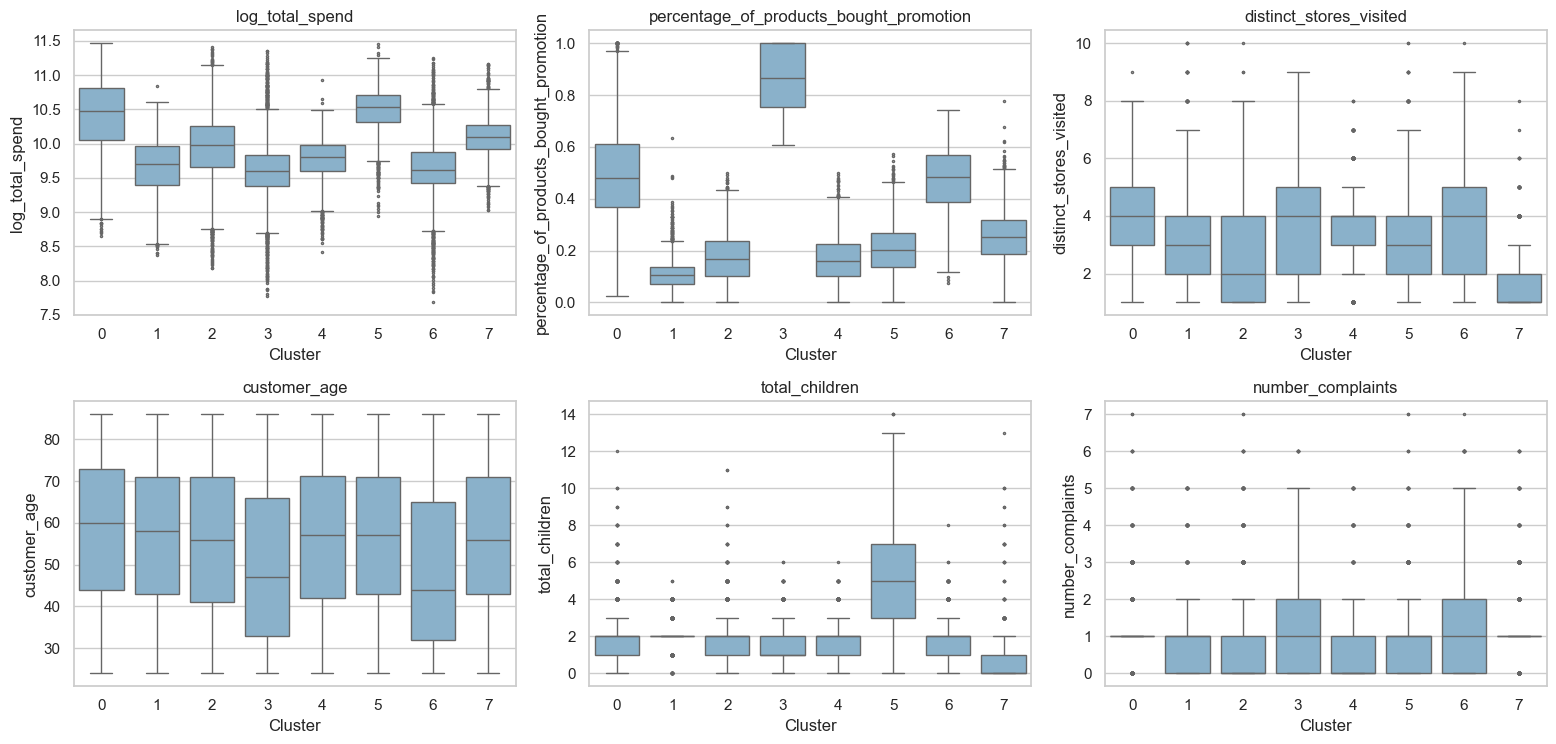

In [72]:
scaled_profile = uc.plot_segment_separation(
    regular,
    label_col="cluster",
)

### 9.3 — Complaint behaviour by segment

Complaint behaviour is reviewed separately because it can support the interpretation of segments with higher service sensitivity or dissatisfaction risk.


In [73]:
complaints_profile = uc.complaint_summary(
    regular,
    label_col="cluster",
    complaint_col="number_complaints",
    threshold=2,
)
display(complaints_profile)


,customers,avg_complaints,pct_complaints_ge_2,max_complaints
cluster,,,,
0,3264,1.11,20.1,7
1,3715,0.78,7.7,5
2,6288,0.74,16.4,7
3,4208,1.03,29.1,6
4,3264,0.56,3.1,5
5,3288,0.93,19.7,7
6,5018,1.11,34.8,7
7,3011,1.07,24.2,6


### 9.4 — Geographic profiling

Geographic variables are used only after clustering, as profiling variables. They are not included in the clustering distance because location could dominate the segmentation and create geographic groups instead of behavioural customer segments.

The scatter plot provides a first visual check of whether any segment is spatially concentrated. Because most customers are located in a dense Lisbon area rectangle, overlap is expected. The purpose of this section is therefore not to define clusters geographically, but to identify whether any segment has a noticeable location pattern that can support interpretation or business actions.


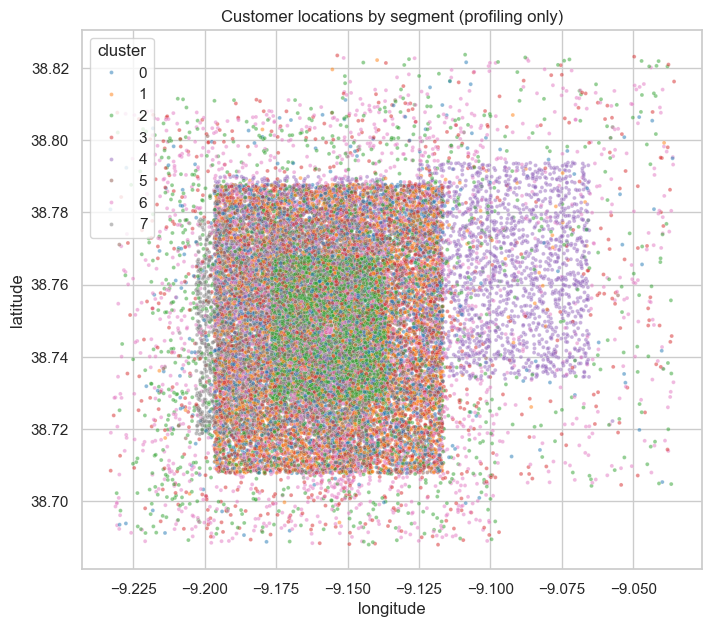

In [74]:
if {'latitude','longitude'}.issubset(regular.columns):
    plt.figure(figsize=(8, 7))
    sns.scatterplot(data=regular, x='longitude', y='latitude',
                    hue='cluster', palette='tab10', s=8, alpha=0.5, legend='full')
    plt.title('Customer locations by segment (profiling only)')
    plt.show()

,customers,mean_latitude,mean_longitude,median_latitude,median_longitude,latitude_std,longitude_std
cluster,,,,,,,
0,3264,38.74868,-9.15611,38.74792,-9.15624,0.02377,0.02533
1,3715,38.74781,-9.15632,38.74749,-9.15660,0.02310,0.02410
2,6288,38.74865,-9.15614,38.74794,-9.15672,0.02004,0.02370
3,4208,38.74788,-9.15496,38.74766,-9.15660,0.02360,0.02670
4,3264,38.76227,-9.12961,38.76209,-9.12351,0.01753,0.03958
5,3288,38.74828,-9.15714,38.74856,-9.15726,0.02336,0.02338
6,5018,38.74835,-9.15338,38.74774,-9.15647,0.02535,0.03042
7,3011,38.74832,-9.17210,38.74894,-9.17190,0.01764,0.01796


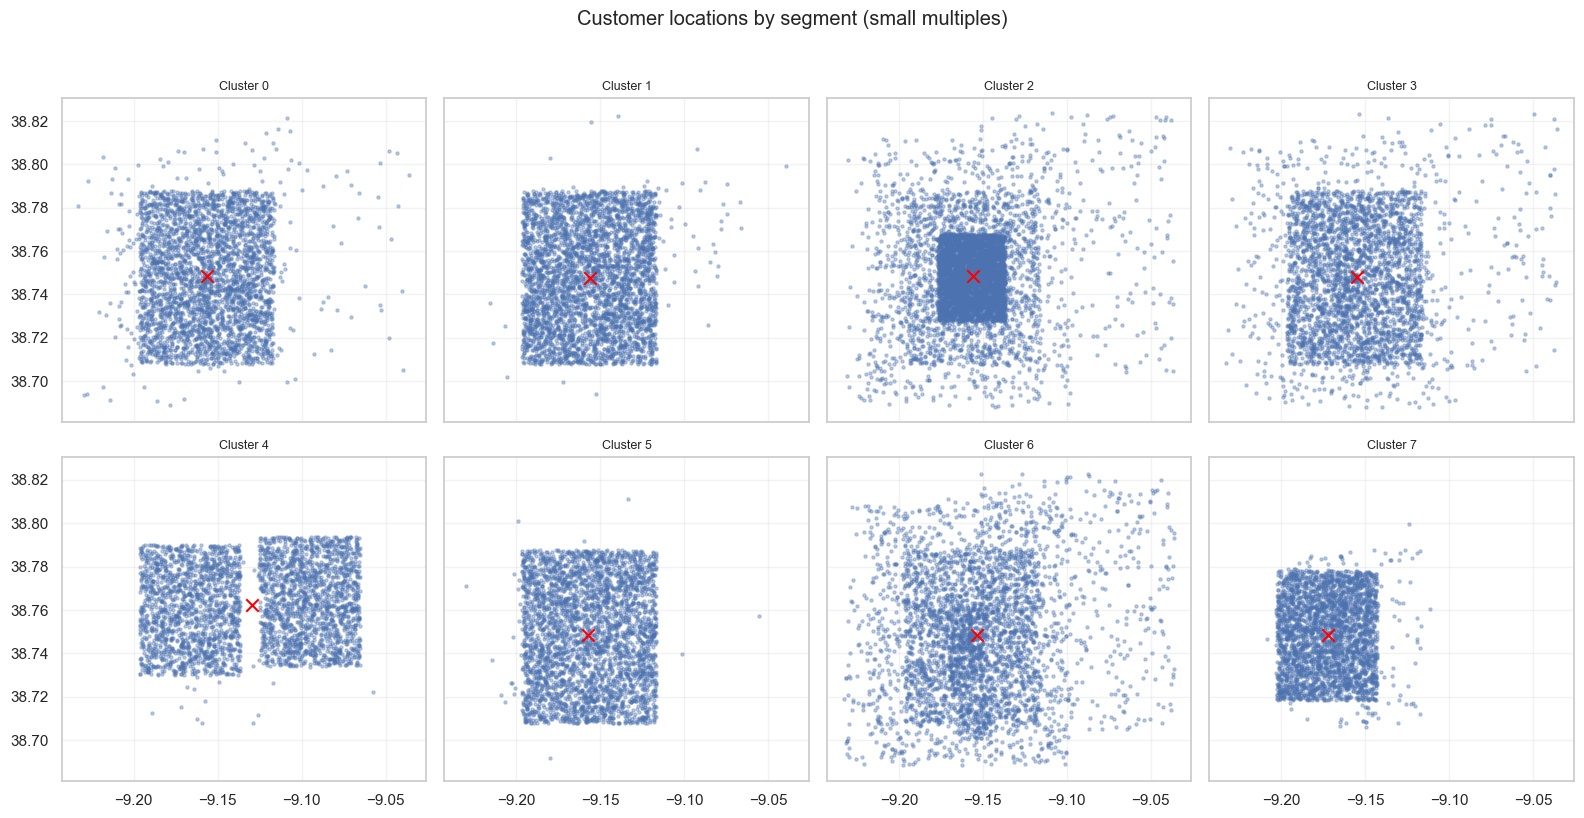

In [75]:
geo_profile = uc.geographic_profile(
    regular,
    label_col="cluster",
)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Geographic interpretation.</b><br><br>
The geographic plot should be interpreted cautiously. A strong overlap between colours means that the final clusters are mainly behavioural rather than geographic, which is desirable because latitude and longitude were intentionally excluded from the clustering distance. If one segment appears more concentrated in a specific area, this can be reported as a profiling insight, but it should not be treated as the main reason for the segment definition.
<br><br>
In practical terms, this analysis can support local marketing decisions, store level planning or regional campaign targeting. However, the final segment names remain based on spending, promotion behaviour, demographic profile and customer stability rather than location alone.
</div>


### 9.5 — Numeric cluster labels

At this stage the model keeps the final groups as numeric labels. Business names are assigned later in the characterization notebook, after the spend, demographic, loyalty and complaint profiles have been reviewed.

In [76]:
cluster_labels = pd.DataFrame({
    "cluster": sorted(regular["cluster"].unique())
})
display(cluster_labels)


,cluster
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7


<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>10) Reattach outliers and export</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">Outliers are not used to fit the KMeans centroids, because their extreme values could distort the segment centres. After the model is fitted on regular customers, the kept aside outliers are projected through the same feature pipeline and assigned to the nearest centroid. This preserves full customer coverage while keeping the learned segments robust.</p>
</div>


In [77]:
segments = uc.reattach_outliers_and_export(
    regular,
    outliers,
    kmeans,
    distance_cols,
    LOGABS,
    scaler,
    DATA_DIR,
    spend_profile=spend_profile,
    complaints_profile=complaints_profile if "complaints_profile" in locals() else None,
)

Outliers assigned: 982
Customers in final file: 33038
cluster
0    3397
1    3740
2    6359
3    4307
4    3323
5    3663
6    5054
7    3195
Name: count, dtype: int64
Saved customer_segments.csv (+ supporting profiles) to ../datasets


In [78]:
segments.head()

,customer_id,cluster
0,3,6
1,4,4
2,5,2
3,7,7
4,8,7


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<code>customer_segments.csv</code> is the required deliverable, containing one final numeric segment assignment per customer. The additional exports support interpretation: <code>segment_summary.csv</code> gives segment sizes, <code>segment_spend_profile.csv</code> supports spend profiling, and <code>segment_complaints_profile.csv</code> highlights service sensitivity. Business names are assigned later, in the characterization notebook.
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>11) Final modelling conclusion</b></h2>
</div>

The final segmentation uses KMeans with `k = 8`, the `spend + promo no groceries` feature set and MinMax scaling.

The choice of `k = 8` is based on the combined evidence from the silhouette grid, UMAP projection, stability analysis and profiling tables. A seven cluster solution was competitive and slightly simpler, but it merged customer behaviours that were more clearly separated when eight clusters were retained. The eight cluster solution therefore provided a better compromise between statistical validation and segment interpretation.

MinMax scaling was selected because the extreme customers had already been separated before modelling and the remaining variables needed to be compared on a common scale. In this context, MinMax keeps category spend variables and the promotion percentage interpretable within the same distance calculation. Robust scaling was considered, but it compressed the regular customer space less clearly for the final feature set.

Groceries were excluded from the clustering distance because they dominated several candidate solutions and made some segments appear too similar. They remain in the profiling stage, where they are important for understanding customer value and household shopping behaviour. This separation keeps the model focused on differentiating purchasing patterns while still using groceries for interpretation.

The category share, age and children alternative produced fewer negative silhouette values, but the UMAP projection showed weaker visual separation. Other compact feature sets reached higher silhouette values, but they used too few variables and produced less useful business profiles. Solutions with very small clusters were also tested, but they were not retained when the negative silhouette rate or instability became too high.

The final model is therefore not chosen by a single metric. It is selected because it remains stable, has acceptable silhouette quality, produces a clear UMAP structure and can be interpreted with the full customer profile. Business names are assigned only in the characterization notebook, after the final numeric labels are compared with spend, demographics, loyalty, complaints, household structure and geography.